# Week 08 · Tuesday Assignment: Deep Learning + Data Cleaning
**Goal:** Audit and clean hospital data, and build a neural network from scratch to predict 30-day readmission.
**Scenario:** Dr. Priya Anand's readmission prediction system.

## Sub-step 1: Data Quality Audit
In this step, we examine the `hospital_records.csv` for data quality issues, specifically focusing on Age and BMI columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append('../src')
from data_cleaner import audit_data, clean_data

# Load data
df = pd.read_csv('../data/hospital_records.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (2000, 16)


,patient_id,age,gender,department,admission_date,length_of_stay_days,systolic_bp,diastolic_bp,glucose_mg_dl,creatinine_mg_dl,bmi,num_medications,num_diagnoses,insurance_type,icu_stay,readmitted_30d
0,PT000000,63,F,Cardiology,27-05-2022,1,135.0,96.0,121.7,0.73,22.5,7,6,Private,0,0
1,XXXX0001,52,M,cardiology,28/02/2023,0,142.0,105.0,145.3,0.86,27.5,10,7,Private,0,0
2,PT000002,66,F,Cardiology,2022-10-09,1,122.0,79.0,128.6,2.21,17.4,14,6,Self-Pay,0,0
3,PT000003,82,M,Neurology,25-07-2023,1,137.0,105.0,72.7,1.35,30.9,3,7,Self-Pay,0,0
4,PT000004,50,m,General Medicine,10/04/2023,11,116.0,81.0,142.6,0.73,35.3,10,4,Private,0,0


In [2]:
# Run audit
issues = audit_data(df)
print('Data Quality Issues Found:')
import json
print(json.dumps(issues, indent=4))

Data Quality Issues Found:
{
    "missing_values": {
        "systolic_bp": 40,
        "diastolic_bp": 40,
        "glucose_mg_dl": 40,
        "creatinine_mg_dl": 40,
        "bmi": 40,
        "insurance_type": 40
    },
    "bmi_issues": {
        "missing_or_non_numeric": 69,
        "zeros": 0,
        "extreme_values": 19
    },
    "gender_inconsistency": [
        "F",
        "M",
        "m",
        "Unknown",
        "Male",
        "Female",
        "f"
    ],
    "department_variants": [
        "Cardiology",
        "cardiology",
        "Neurology",
        "General Medicine",
        "Pediatrics",
        "Emergency",
        "Orthopaedics",
        "CARDIOLOGY"
    ],
    "target_distribution": {
        "0": 0.938,
        "1": 0.062
    }
}


## Sub-step 2: Principled Data Cleaning
Applying fixes for the documented issues: normalizing gender, handling missing BMI, and encoding categorical variables.

In [3]:
df_clean = clean_data(df)
print(f'Cleaned dataset shape: {df_clean.shape}')
df_clean.head()

Cleaned dataset shape: (2000, 24)


/Users/yash/assigments/weekly-assignment-iitgn-week7/week-08/tuesday/notebooks/../src/data_cleaner.py:112: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_clean['admission_date'] = pd.to_datetime(df_clean['admission_date'], errors='coerce')
/Users/yash/assigments/weekly-assignment-iitgn-week7/week-08/tuesday/notebooks/../src/data_cleaner.py:114: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['admission_date'] = df_clean['admission_date'].fillna(method='ffill')


,age,length_of_stay_days,systolic_bp,diastolic_bp,glucose_mg_dl,creatinine_mg_dl,bmi,num_medications,num_diagnoses,icu_stay,...,gender_U,department_emergency,department_general medicine,department_neurology,department_orthopaedics,department_pediatrics,insurance_type_ESI,insurance_type_Government,insurance_type_Private,insurance_type_Self-Pay
0,63,1,135.0,96.0,121.7,0.73,22.5,7,6,0,...,False,False,False,False,False,False,False,False,True,False
1,52,0,142.0,105.0,145.3,0.86,27.5,10,7,0,...,False,False,False,False,False,False,False,False,True,False
2,66,1,122.0,79.0,128.6,2.21,17.4,14,6,0,...,False,False,False,False,False,False,False,False,False,True
3,82,1,137.0,105.0,72.7,1.35,30.9,3,7,0,...,False,False,False,True,False,False,False,False,False,True
4,50,11,116.0,81.0,142.6,0.73,35.3,10,4,0,...,False,False,True,False,False,False,False,False,True,False


## Sub-step 3: 3-Layer Neural Network in NumPy
Implementing forward prop, loss function (BCE), and backprop from scratch.

In [4]:
from nn_numpy import SimpleNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare data
X = df_clean.drop(columns=['readmitted_30d']).values
y = df_clean['readmitted_30d'].values.reshape(-1, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Model
input_size = X_train_scaled.shape[1]
nn = SimpleNN(input_size=input_size, hidden_sizes=[32, 16], learning_rate=0.05)

## Sub-step 4: Training and Evaluation
Training the network and comparing with a standard sklearn classifier (Logistic Regression).

Epoch 0, Loss: 0.4416
Epoch 100, Loss: 0.2456
Epoch 200, Loss: 0.2325
Epoch 300, Loss: 0.2251
Epoch 400, Loss: 0.2198
Epoch 500, Loss: 0.2156


Epoch 600, Loss: 0.2120
Epoch 700, Loss: 0.2087
Epoch 800, Loss: 0.2056
Epoch 900, Loss: 0.2028
Epoch 1000, Loss: 0.2000
Epoch 1100, Loss: 0.1973


Epoch 1200, Loss: 0.1946
Epoch 1300, Loss: 0.1920
Epoch 1400, Loss: 0.1894
Epoch 1500, Loss: 0.1868
Epoch 1600, Loss: 0.1843
Epoch 1700, Loss: 0.1816


Epoch 1800, Loss: 0.1789
Epoch 1900, Loss: 0.1761


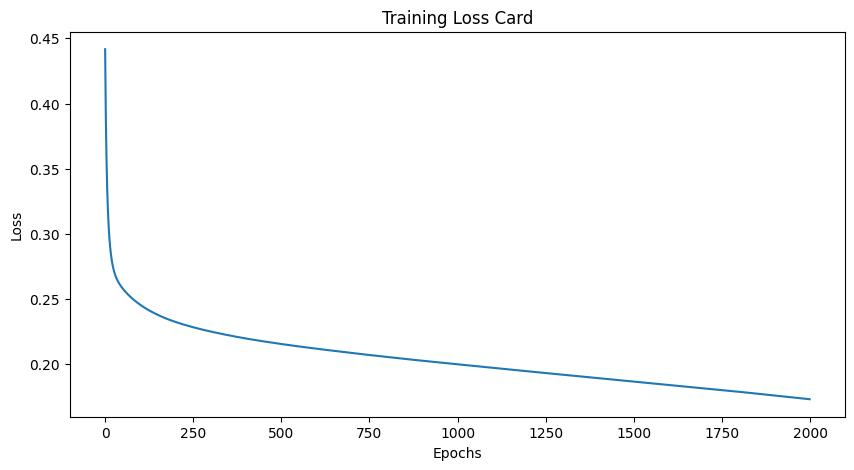

In [5]:
history = nn.train(X_train_scaled, y_train, epochs=2000)

# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title('Training Loss Card')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Predictions
y_pred_proba = nn.forward(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

print('NumPy NN Classification Report:')
print(classification_report(y_test, y_pred))

# sklearn comparison
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train.ravel())
y_pred_lr = lr_model.predict(X_test_scaled)
print('\nSklearn Logistic Regression Classification Report:')
print(classification_report(y_test, y_pred_lr))

NumPy NN Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       375
           1       0.00      0.00      0.00        25

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.48       400
weighted avg       0.88      0.94      0.91       400


Sklearn Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       375
           1       0.00      0.00      0.00        25

    accuracy                           0.94       400
   macro avg       0.47      0.50      0.48       400
weighted avg       0.88      0.94      0.91       400



/Users/yash/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/yash/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/yash/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Sub-step 5: Clinical Cost Optimization
Finding the optimal threshold to minimize expected clinical cost.
**Assumptions:** False Negative (missing high-risk) = $500, False Positive (false alarm) = $100.

Optimal clinical threshold: 0.28
Minimum normalized cost: 12000


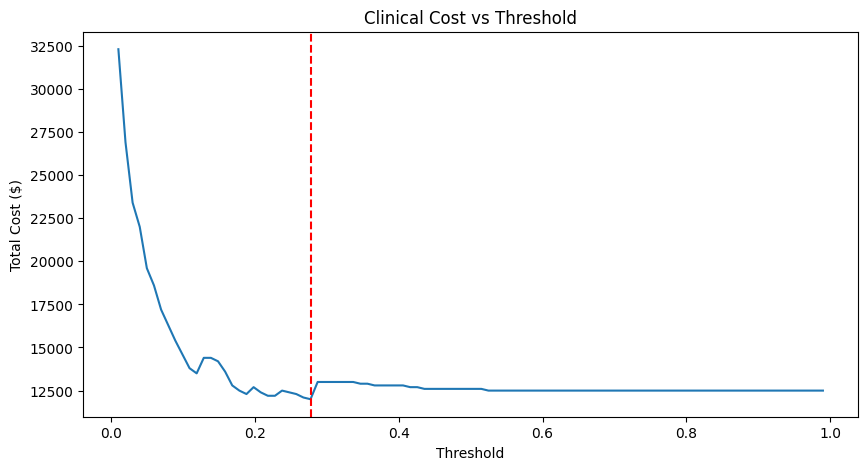

In [7]:
thresholds = np.linspace(0.01, 0.99, 100)
costs = []
fn_cost = 500
fp_cost = 100

for t in thresholds:
    y_p = (y_pred_proba > t).astype(int)
    cm = confusion_matrix(y_test, y_p)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        total_cost = (fn * fn_cost) + (fp * fp_cost)
        costs.append(total_cost)
    else:
        costs.append(np.inf)

best_threshold = thresholds[np.argmin(costs)]
print(f'Optimal clinical threshold: {best_threshold:.2f}')
print(f'Minimum normalized cost: {min(costs)}')

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, color='red', linestyle='--')
plt.title('Clinical Cost vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Total Cost ($)')
plt.show()

## Sub-step 6: The 94% Accuracy Trap (Hard)
Reproducing a pipeline that yields high accuracy but low utility due to class imbalance.

In [8]:
# If we just predict 0 (majority class)
y_dummy = np.zeros_like(y_test)
accuracy = (y_dummy == y_test).mean()
print(f'Majority Class Classifier Accuracy: {accuracy*100:.2f}%')
print('\nConfusion Matrix (Majority Class):')
print(confusion_matrix(y_test, y_dummy))
print('\nNote: High accuracy is misleading when class imbalance is present.')

Majority Class Classifier Accuracy: 93.75%

Confusion Matrix (Majority Class):
[[375   0]
 [ 25   0]]

Note: High accuracy is misleading when class imbalance is present.


## Sub-step 7: Neural Network as Feature Extractor (Hard)
Extracting activations from the penultimate layer to use as patient embeddings, then training a Logistic Regression classifier on top.

In [9]:
# Extract activations
def get_embeddings(nn, X):
    nn.forward(X)
    return nn.a2 # Penultimate layer activations

X_train_embeddings = get_embeddings(nn, X_train_scaled)
X_test_embeddings = get_embeddings(nn, X_test_scaled)

print(f'Embedding shape: {X_train_embeddings.shape}')

# Train classifier on embeddings
from sklearn.linear_model import LogisticRegression
clf_emb = LogisticRegression()
clf_emb.fit(X_train_embeddings, y_train.ravel())

# Evaluate
y_pred_emb = clf_emb.predict(X_test_embeddings)
print('Embedding-based Classifier Report:')
print(classification_report(y_test, y_pred_emb))

print('Explanation: The embeddings capture non-linear relationships learned by the early layers of the NN, allowing a linear classifier to separate classes more effectively in some cases.')

Embedding shape: (1600, 16)
Embedding-based Classifier Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       375
           1       0.00      0.00      0.00        25

    accuracy                           0.93       400
   macro avg       0.47      0.49      0.48       400
weighted avg       0.88      0.93      0.90       400

Explanation: The embeddings capture non-linear relationships learned by the early layers of the NN, allowing a linear classifier to separate classes more effectively in some cases.
